# SpatialTransformer Demo

This notebook demonstrates how to use the `SpatialTransformer` module from `neurite` to warp an
image using a deformation (flow) field.

In this example we:

- Generate a simple checkerboard image
- Create a constant translation flow field (shifting the image 10 pixels to the right)
  in a differentiable manner
- Instantiate the `SpatialTransformer` with the image dimensions
- Apply the transformation and visualize the original and warped images

Make sure you have the `neurite` package installed and available in your
Python environment.

In [1]:
import os
os.environ['NEURITE_BACKEND'] = 'pytorch'

import torch
import matplotlib.pyplot as plt

In [50]:
# Set device to GPU if available, otherwise CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [56]:
# One more thing before we start -- making something to plot the flow field.
import numpy as np
def visualize_flow_field(flow_field: torch.Tensor) -> None:
    """
    Visualize a 2D flow field using a matplotlib quiver plot.
    
    Parameters
    ----------
    flow_field : torch.Tensor
        Tensor of shape (1, 2, H, W) representing a 2D flow field.
        The first channel contains horizontal displacements,
        while the second channel contains vertical displacements.
    
    Returns
    -------
    None
        Displays a matplotlib quiver plot of the flow field.
    """

    # Ensure the tensor is on CPU and remove batch dimension.
    flow_cpu = flow_field.cpu()
    flow_np = flow_cpu[0].permute(1, 2, 0).detach().numpy()  # Shape: (H, W, 2)

    # Create a grid of coordinates.
    H, W, _ = flow_np.shape
    y, x = np.mgrid[0:H, 0:W]

    # Separate horizontal and vertical flow components.
    u = flow_np[:, :, 0]
    v = flow_np[:, :, 1]

    plt.figure(figsize=(6, 6))
    plt.quiver(x, y, u, v, angles='xy', scale_units='xy', scale=1)
    plt.gca().invert_yaxis()  # Invert y-axis to match image coordinates.
    plt.title('Flow Field Visualization')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.tight_layout()
    plt.show()


### Make an example checkerboard image

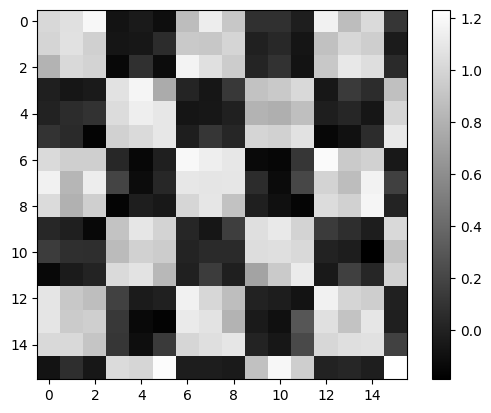

In [107]:
# Import a sample checkerboard image generator
from neurite.torch.utils import make_sample_checkerboard_image

# Define the image shape: (Batch, Channel, Height, Width)
img_shape = (1, 1, 16, 16)

# Generate a checkerboard image on the specified device
image = make_sample_checkerboard_image(img_shape, device=device)

# Optionally add some noise by uncommmenting the below line 
image += torch.randn_like(image) * 0.1  # Make St. Dev = 0.1, but you can change it!

plt.imshow(image[0, 0], cmap="gray")
plt.colorbar()

### Make a simple flow field pre-defined in `neurite`

torch.Size([1, 2, 16, 16])


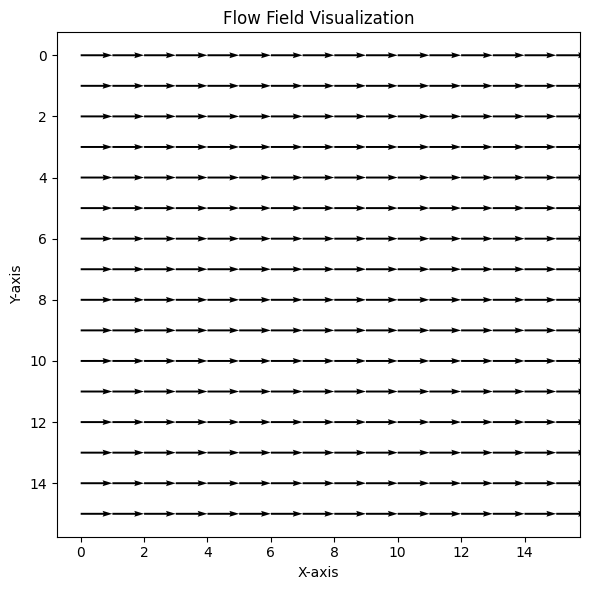

In [116]:
from neurite.torch.utils import make_sample_flow

# Make the flow field to translate the entire image by 1 pixel
flow_field = make_sample_flow(image.shape, shift_size=1)

# Optionally add some noise to the field by uncommenting the line below!
# flow_field *= torch.randn_like(flow_field)  # Flow will still only be left and right though

print(flow_field.shape)

visualize_flow_field(flow_field)

### Defining the spatial transformer instance

In [117]:
# Import SpatialTransformer from neurite
from neurite.torch.layers import SpatialTransformer

spatial_transformer = SpatialTransformer(image.shape[2:], device=device)

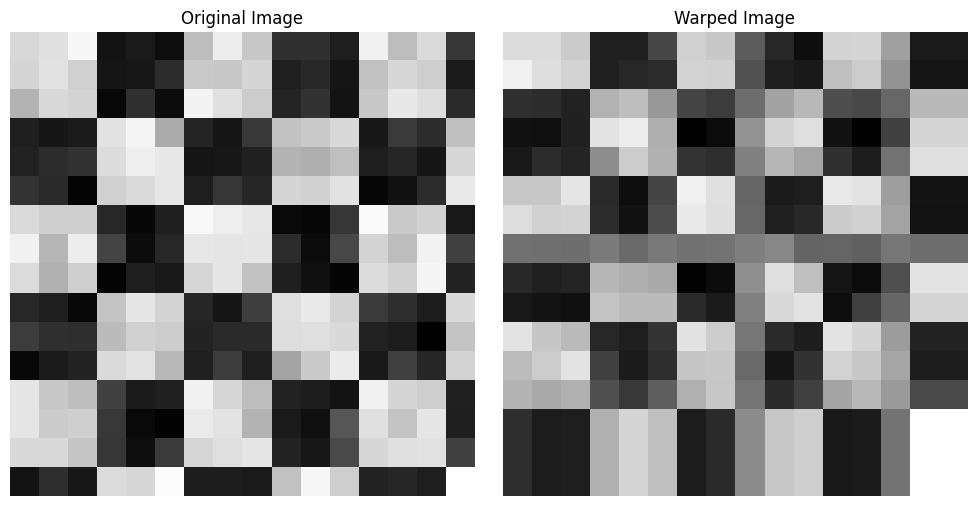

In [118]:
# Apply the spatial transformation
warped = spatial_transformer(
    image,
    flow_field.permute(0, 2, 3, 1)
)

# Plot the original and warped images side by side
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image[0, 0].cpu(), cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(warped[0, 0].cpu(), cmap='gray')
ax[1].set_title('Warped Image')
ax[1].axis('off')

plt.tight_layout()
plt.show()


In [124]:
def create_translation_flow(shape, translation, device):
    """
    Create a constant translation flow field.
    
    Parameters
    ----------
    shape : tuple
        Shape of the image tensor in the format (B, C, H, W).
    translation : tuple
        Translation offsets (tx, ty) in pixels.
    device : torch.device or str
        Device for the tensor.
    
    Returns
    -------
    torch.Tensor
        Flow field of shape (B, H, W, 2) representing the translation.
    """
    batch, _, h, w = shape
    flow = torch.zeros(batch, 2, h, w, device=device)
    flow[:, 0, :, :] = translation[0]
    flow[:, 1, :, :] = translation[1]
    # Permute to (B, H, W, 2) as required by grid_sample
    return flow.permute(0, 2, 3, 1)


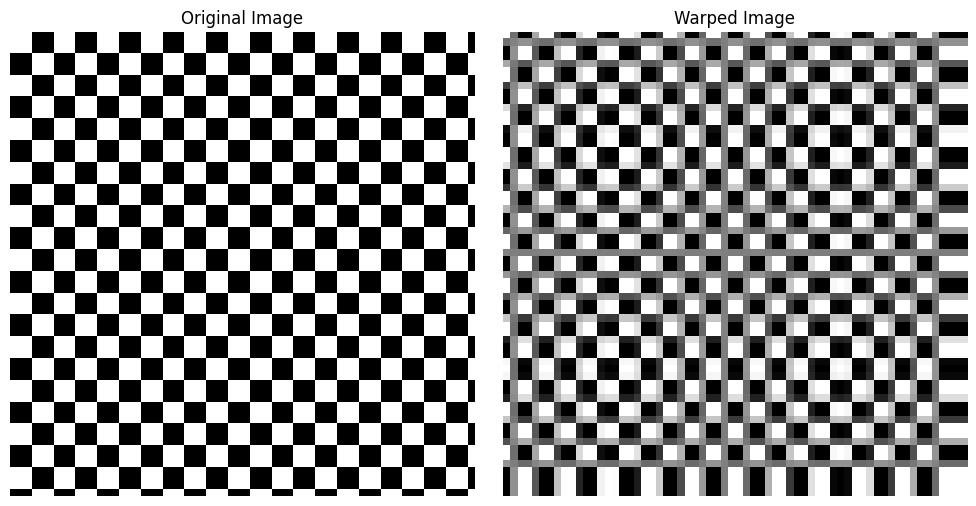

In [126]:
# Define the image shape: (Batch, Channel, Height, Width)
img_shape = (1, 1, 64, 64)

# Generate a checkerboard image on the specified device
image = make_sample_checkerboard_image(img_shape, device=device)

# Create a flow field that translates the image 10 pixels to the right
translation = (1, 1)  # (tx, ty)
flow_field = create_translation_flow(img_shape, translation, device)

# Instantiate the SpatialTransformer
# The spatial size is defined by the height and width of the image
sp_trans = SpatialTransformer(img_shape[2:], device=device)

# Apply the spatial transformation
warped = sp_trans(image, flow_field)

# Plot the original and warped images side by side
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image[0, 0].cpu(), cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(warped[0, 0].cpu(), cmap='gray')
ax[1].set_title('Warped Image')
ax[1].axis('off')

plt.tight_layout()
plt.show()


## Conclusion

In this notebook we:

- Created a synthetic checkerboard image
- Defined a simple translation flow field
- Warped the image using the `SpatialTransformer`

You can experiment with different deformation fields and image types to suit
your application.